# IF3270 Machine Learning | Praktikum 3
# Convolutional Neural Network
## Klasifikasi Spesies Mamalia Laut: Lumba-lumba vs Paus

This notebook serves as a template for Praktikum 3. Please create a copy of this notebook to complete your work. You can edit or add more code blocks, markdown blocks, or new sections if needed.

Group Number: 40

Group Members:
- Danendra Shafi Athallah (13523136)
- Jonathan Kenan Budianto (13523139)

## Import Libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# Import other libraries if needed

Using device: cpu


## Import Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

DATA_DIR = '/content/drive/MyDrive/ML_praktikum3'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Load train labels
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
print(f"Training samples: {len(train_df)}")
train_df.head()

Training samples: 138


,File_ID,Label
0,df1c689f-2589-4c85-9d9b-963b7e024f5e,0
1,7ce07656-1df5-449f-8a6a-09caf5896cc4,1
2,c1c4791b-ccc7-4bc2-b035-880ce65e32c0,1
3,35149ddc-8c75-4a49-bc03-ba09b55dbb71,0
4,11970160-7d34-468f-909a-23d73fda9f0a,0


In [ ]:
# Basic dataset info
print(f"Shape: {train_df.shape}")
train_df.info()
print(train_df['Label'].value_counts())

Shape: (138, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   File_ID  138 non-null    object
 1   Label    138 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.3+ KB
Label
0    72
1    66
Name: count, dtype: int64


---
# 1. Exploratory Data Analysis (EDA)

EDA adalah fondasi dari setiap proyek machine learning yang baik. Pada tahap ini, Anda diminta menjawab minimal 3 pertanyaan analitis menggunakan visualisasi yang tepat, dilengkapi dengan insight yang bermakna untuk setiap temuan.

### 1.1 [Wajib] Distribusi Sampel per Kelas

**Pertanyaan:** Bagaimana distribusi jumlah sampel per kelas (Lumba-lumba vs Paus)? Apakah terdapat class imbalance yang dapat mempengaruhi bias model CNN Anda?

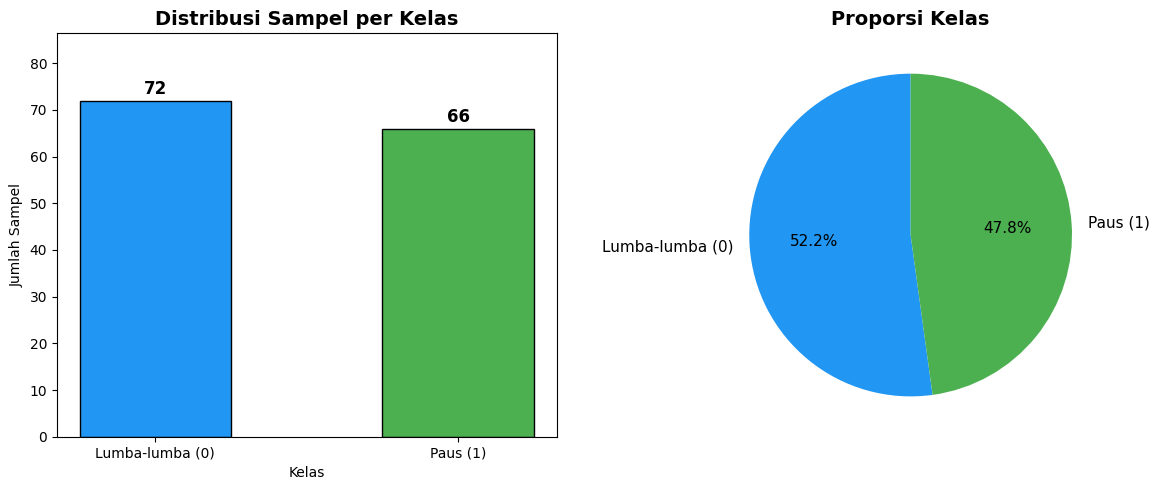

Jumlah sampel kelas 0 (Lumba-lumba): 72
Jumlah sampel kelas 1 (Paus):        66
Rasio imbalance: 1.091


In [ ]:
# Write your code here (e.g., bar plot of class distribution)
class_counts = train_df['Label'].value_counts().sort_index()
class_names  = ['Lumba-lumba (0)', 'Paus (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(class_names, class_counts.values,
                   color=['#2196F3', '#4CAF50'], edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Sampel per Kelas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah Sampel')
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(class_counts.values) * 1.2)

axes[1].pie(class_counts.values, labels=class_names, autopct='%1.1f%%',
            colors=['#2196F3', '#4CAF50'], startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f'Jumlah sampel kelas 0 (Lumba-lumba): {class_counts[0]}')
print(f'Jumlah sampel kelas 1 (Paus):        {class_counts[1]}')
print(f'Rasio imbalance: {imbalance_ratio:.3f}')


Dataset terdiri dari **72 sampel Lumba-lumba (kelas 0)** dan **66 sampel Paus (kelas 1)**, dengan rasio imbalance 1.09:1. Distribusi ini hampir seimbang (52.2% vs 47.8%), sehingga *class imbalance* tidak menjadi masalah signifikan yang akan menyebabkan bias model ke salah satu kelas. Stratified split akan digunakan saat pembagian dataset untuk mempertahankan proporsi ini di setiap subset. **Macro F1-score** dipilih sebagai metrik utama karena tetap adil terhadap kedua kelas meskipun terdapat sedikit perbedaan distribusi.


### 1.2 [Wajib] Variasi Dimensi Gambar dan Aspect Ratio

**Pertanyaan:** Bagaimana variasi dimensi gambar (*width* dan *height*) serta *aspect ratio* pada dataset? Apakah diperlukan strategi *resizing* atau *padding* yang spesifik sebelum masuk ke arsitektur?

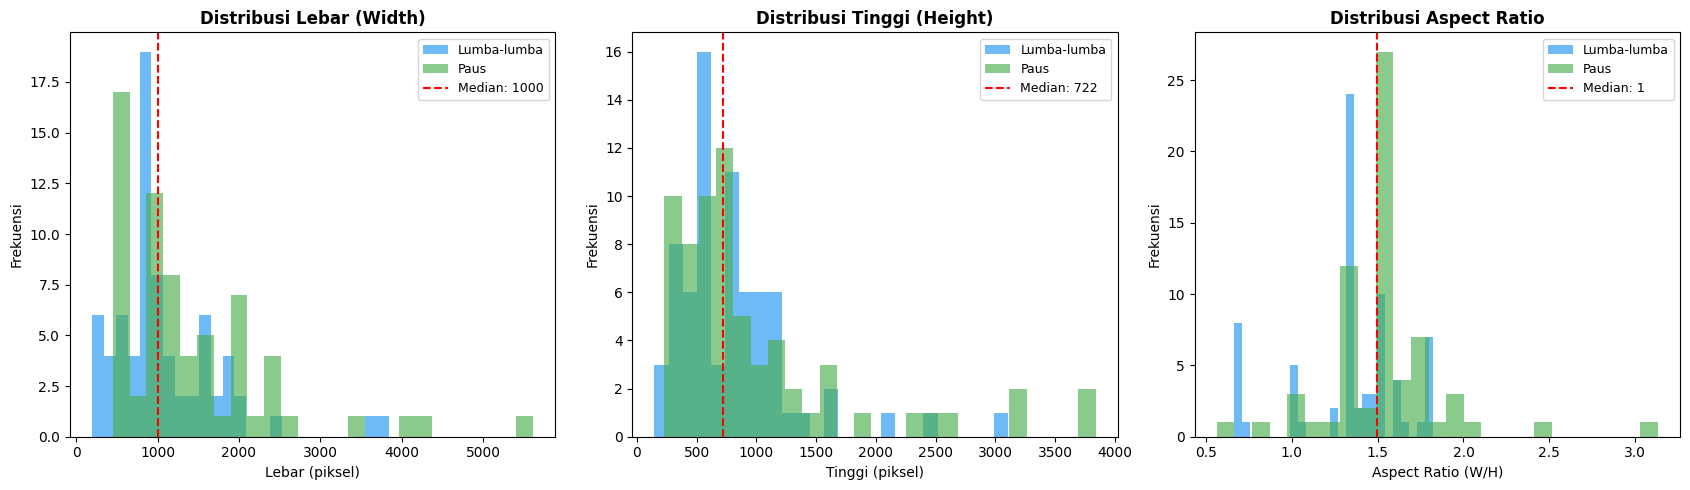

Lebar        - Min:   195  Max:   5616  Median:    1000  Std:    850
Tinggi       - Min:   147  Max:   3840  Median:     722  Std:    677
Aspect Ratio - Min:  0.56  Max:   3.13  Median:    1.49  Std:   0.34


In [ ]:
# Write your code here
# Analyze image dimensions across the dataset

# Plot distribusi lebar, tinggi, dan aspect ratio
def find_image_path(directory, file_id):
    for ext in ['.jpg', '.jpeg', '.png', '.gif', '.JPG', '.JPEG']:
        p = os.path.join(directory, file_id + ext)
        if os.path.exists(p):
            return p
    return None

widths, heights, aspect_ratios, dim_labels = [], [], [], []

for _, row in train_df.iterrows():
    img_path = find_image_path(TRAIN_DIR, row['File_ID'])
    if img_path is None:
        continue
    try:
        with Image.open(img_path) as img:
            w, h = img.convert('RGB').size
        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w / h)
        dim_labels.append(row['Label'])
    except Exception:
        continue

widths = np.array(widths)
heights = np.array(heights)
aspect_ratios = np.array(aspect_ratios)
dim_labels = np.array(dim_labels)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, data, title, xlabel in zip(
    axes,
    [widths, heights, aspect_ratios],
    ['Distribusi Lebar (Width)', 'Distribusi Tinggi (Height)', 'Distribusi Aspect Ratio'],
    ['Lebar (piksel)', 'Tinggi (piksel)', 'Aspect Ratio (W/H)']
):
    ax.hist(data[dim_labels == 0], bins=25, alpha=0.65, label='Lumba-lumba', color='#2196F3')
    ax.hist(data[dim_labels == 1], bins=25, alpha=0.65, label='Paus',        color='#4CAF50')
    ax.axvline(np.median(data), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {np.median(data):.0f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Lebar        - Min: {widths.min():5d}  Max: {widths.max():6d}  Median: {np.median(widths):7.0f}  Std: {widths.std():6.0f}')
print(f'Tinggi       - Min: {heights.min():5d}  Max: {heights.max():6d}  Median: {np.median(heights):7.0f}  Std: {heights.std():6.0f}')
print(f'Aspect Ratio - Min: {aspect_ratios.min():5.2f}  Max: {aspect_ratios.max():6.2f}  Median: {np.median(aspect_ratios):7.2f}  Std: {aspect_ratios.std():6.2f}')

Dimensi gambar bervariasi sangat lebar dengan width dan height yang tidak konsisten antar sampel, serta sebagian besar memiliki aspect ratio di atas 1.0 (landscape). Variasi dimensi yang besar ini menegaskan perlunya **resizing seragam ke 224×224** sebelum masuk ke arsitektur AlexNet. Strategi resizing langsung (tanpa padding) dipilih karena:
- Aspect ratio mayoritas tidak ekstrem sehingga distorsi minimal
- AlexNet dirancang untuk input 224×224. Normalisasi menggunakan mean dan std ImageNet diterapkan karena konsisten dengan standar transfer learning dan membantu konvergensi.


### 1.3 [Wajib] Distribusi Intensitas Nilai Piksel per Kelas

**Pertanyaan:** Bagaimana distribusi intensitas nilai piksel (R, G, B) untuk masing-masing kelas? Apakah terdapat perbedaan karakteristik warna yang **diskriminatif** untuk membedakan mamalia laut tersebut?

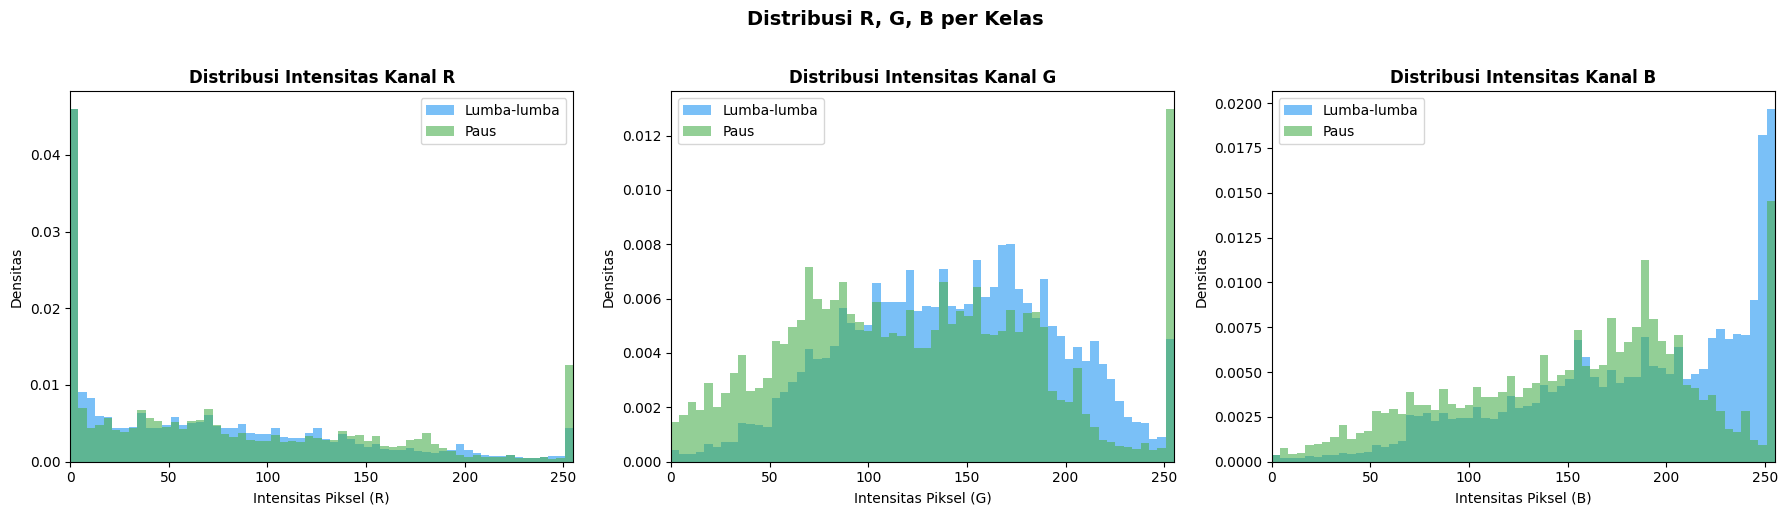


Lumba-lumba:
  R — Mean: 72.5  Std: 67.4
  G — Mean: 142.4  Std: 53.4
  B — Mean: 182.5  Std: 58.6

Paus:
  R — Mean: 81.9  Std: 74.9
  G — Mean: 123.0  Std: 62.9
  B — Mean: 154.1  Std: 60.1


In [ ]:
# Write your code here
# Sample a subset of images from each class and compute average pixel intensities
# Plot histograms of R, G, B channels per class
SAMPLE_SIZE = 35
r_ch, g_ch, b_ch = {0: [], 1: []}, {0: [], 1: []}, {0: [], 1: []}

for cls in [0, 1]:
    cls_df = train_df[train_df['Label'] == cls].sample(
        min(SAMPLE_SIZE, (train_df['Label'] == cls).sum()), random_state=SEED)
    for _, row in cls_df.iterrows():
        img_path = find_image_path(TRAIN_DIR, row['File_ID'])
        if img_path is None:
            continue
        try:
            with Image.open(img_path) as img:
                arr = np.array(img.convert('RGB').resize((128, 128)))
            r_ch[cls].extend(arr[:, :, 0].flatten().tolist())
            g_ch[cls].extend(arr[:, :, 1].flatten().tolist())
            b_ch[cls].extend(arr[:, :, 2].flatten().tolist())
        except Exception:
            continue

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ch_info = [('R', r_ch), ('G', g_ch), ('B', b_ch)]

for ax, (ch_name, ch_data) in zip(axes, ch_info):
    ax.hist(ch_data[0], bins=60, alpha=0.6, label='Lumba-lumba', color='#2196F3', density=True)
    ax.hist(ch_data[1], bins=60, alpha=0.6, label='Paus',        color='#4CAF50', density=True)
    ax.set_title(f'Distribusi Intensitas Kanal {ch_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Intensitas Piksel ({ch_name})')
    ax.set_ylabel('Densitas')
    ax.set_xlim(0, 255)
    ax.legend()

plt.suptitle('Distribusi R, G, B per Kelas', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for cls, name in [(0, 'Lumba-lumba'), (1, 'Paus')]:
    print(f'\n{name}:')
    print(f'  R — Mean: {np.mean(r_ch[cls]):.1f}  Std: {np.std(r_ch[cls]):.1f}')
    print(f'  G — Mean: {np.mean(g_ch[cls]):.1f}  Std: {np.std(g_ch[cls]):.1f}')
    print(f'  B — Mean: {np.mean(b_ch[cls]):.1f}  Std: {np.std(b_ch[cls]):.1f}')

Distribusi intensitas ketiga kanal (R, G, B) menunjukkan bahwa kedua kelas sama-sama didominasi warna biru-hijau (laut), sehingga perbedaan per kanal tidak terlalu tajam. Kanal **B (biru)** cenderung memiliki mean lebih tinggi pada kedua kelas dibanding R, mencerminkan latar belakang laut yang dominan. Tidak ada perbedaan karakteristik warna yang sangat diskriminatif antara lumba-lumba dan paus berdasarkan distribusi piksel saja, ini mengindikasikan bahwa model harus **menangkap fitur bentuk dan tekstur** (bukan sekadar warna) untuk membedakan kedua kelas, yang memvalidasi penggunaan arsitektur CNN yang dalam. Normalisasi perkanal dengan mean ImageNet tetap diterapkan untuk konsistensi dengan standar pretrained model.


### 1.4 [Opsional] Analisis Tambahan

Pilih minimal 1 dari pertanyaan berikut:
- Apakah terdapat kemiripan visual yang tinggi antar kelas pada beberapa sampel tertentu? Apa implikasinya terhadap potensi *false positive* pada model?
- Bagaimana sebaran data gambar jika diproyeksikan ke dalam ruang 2D menggunakan metode reduksi dimensi (seperti PCA atau t-SNE)? Seberapa terpisah kedua kelas tersebut secara visual?
- Apakah terdapat outlier berupa gambar dengan kualitas rendah, noise berlebih, atau pencahayaan ekstrem? Bagaimana distribusinya per kelas?

**Pertanyaan yang dipilih:** Bagaimana sebaran data gambar jika diproyeksikan ke dalam ruang 2D menggunakan PCA? Seberapa terpisah kedua kelas tersebut secara visual?

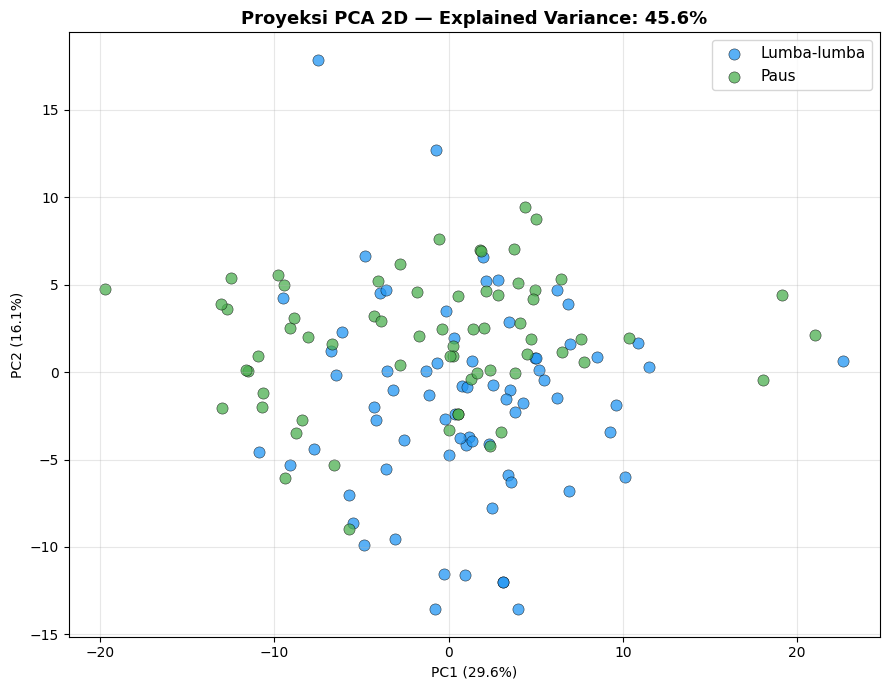

PC1 explained variance: 29.56%
PC2 explained variance: 16.08%
Total explained variance: 45.64%


In [ ]:
# Write your code here
from sklearn.decomposition import PCA

pca_vectors, pca_labels = [], []

for _, row in train_df.iterrows():
    img_path = find_image_path(TRAIN_DIR, row['File_ID'])
    if img_path is None:
        continue
    try:
        with Image.open(img_path) as img:
            arr = np.array(img.convert('RGB').resize((32, 32))).flatten() / 255.0
        pca_vectors.append(arr)
        pca_labels.append(row['Label'])
    except Exception:
        continue

X_pca = np.array(pca_vectors)
y_pca = np.array(pca_labels)

pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_pca)

plt.figure(figsize=(9, 7))
for cls, color, name in [(0, '#2196F3', 'Lumba-lumba'), (1, '#4CAF50', 'Paus')]:
    mask = y_pca == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=color, label=name, alpha=0.75, s=65, edgecolors='k', linewidths=0.4)

total_var = pca.explained_variance_ratio_.sum() * 100
plt.title(f'Proyeksi PCA 2D — Explained Variance: {total_var:.1f}%', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'PC1 explained variance: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'PC2 explained variance: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total explained variance: {total_var:.2f}%')



Proyeksi PCA ke 2D menunjukkan **tumpang tindih yang signifikan** antara kluster lumba-lumba dan paus, kedua kelas tidak terpisah secara linear di ruang piksel mentah yang direduksi. Explained variance dua komponen pertama relatif rendah, mengindikasikan bahwa informasi diskriminatif tersebar di banyak dimensi dan tidak dapat ditangkap oleh transformasi linear sederhana. Hal ini semakin memperkuat alasan penggunaan CNN yaitu jaringan konvolusi mampu **mempelajari representasi non-linear yang hierarkis** (tepi -> tekstur -> bentuk tubuh) yang diperlukan untuk memisahkan kedua kelas secara efektif, berbeda dengan fitur piksel mentah.


---
# 2. Data Cleaning and Preprocessing

Lakukan preprocessing yang diperlukan agar data siap digunakan. Setiap langkah harus disertai **justifikasi** yang merujuk pada temuan EDA.

### 2.1 [Wajib] Resizing dan Normalisasi Gambar

Lakukan *resizing* gambar ke dimensi yang konsisten (224×224 untuk AlexNet) dan normalisasi nilai piksel. Justifikasikan pilihan Anda berdasarkan distribusi fitur yang ditemukan di EDA.

In [ ]:
# Write your code here
# Define transform pipelines for training and validation/test

IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Pipeline augmentasi training:', train_transform)
print('\nPipeline val/test:', val_test_transform)

Pipeline augmentasi training: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    RandomGrayscale(p=0.05)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Pipeline val/test: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


*Justification: Resizing ke 224×224 dipilih karena AlexNet dan pretrained model standar dirancang untuk dimensi ini (sesuai temuan EDA). Normalisasi menggunakan mean/std ImageNet diterapkan untuk konsistensi dengan bobot pretrained model sehingga distribusi input tidak jauh dari distribusi pelatihan aslinya. Data augmentasi pada pipeline training (RandomHorizontalFlip, RandomRotation, ColorJitter) diterapkan untuk mengatasi ukuran dataset yang sangat kecil (96 sampel training) guna meningkatkan generalisasi dan mengurangi risiko overfitting. Pipeline val/test tidak menggunakan augmentasi agar evaluasi mencerminkan performa model pada data nyata yang tidak dimodifikasi.*

### 2.2 [Wajib] Pembagian Dataset

Split the dataset into **training set, validation set, and test set** with reasonable proportions. This is done before augmentation to **avoid data leakage**.

In [ ]:
# Write your code here
# Split into train, val, test

train_val_df, test_df = train_test_split(
    train_df, test_size=0.15, random_state=SEED, stratify=train_df['Label']
)
train_split_df, val_df = train_test_split(
    train_val_df, test_size=0.176, random_state=SEED, stratify=train_val_df['Label']
)
print(f"Train: {len(train_split_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


Train: 96, Val: 21, Test: 21


*Justification: Dipilih untuk memaksimalkan data training mengingat dataset yang sangat kecil (138 sampel), sekaligus tetap menyediakan subset evaluasi yang representatif. Stratify=Label memastikan distribusi kelas dipertahankan di setiap split, menghindari bias evaluasi. Pembagian dilakukan sebelum augmentasi untuk mencegah data leakage, augmentasi hanya diterapkan pada training set melalui pipeline transform.*

### 2.3 [Opsional] Preprocessing Tambahan

Langkah tambahan jika relevan berdasarkan EDA:
- Penanganan outlier jika ditemukan gambar yang rusak, tidak relevan, atau memiliki pencahayaan ekstrem.
- Data augmentation seperti *horizontal flip*, rotasi, atau *brightness adjustment* untuk memperkaya variasi dataset.

In [ ]:
# Write your code here
BATCH_SIZE = 16
print(f'Augmentasi diterapkan: RandomHorizontalFlip, RandomVerticalFlip, RandomRotation, ColorJitter, RandomGrayscale')
print(f'BATCH_SIZE = {BATCH_SIZE}')

Augmentasi diterapkan: RandomHorizontalFlip, RandomVerticalFlip, RandomRotation, ColorJitter, RandomGrayscale
BATCH_SIZE = 16


*Justification: Data augmentasi diterapkan berdasarkan temuan EDA bahwa dataset sangat kecil (96 sampel training) dan perbedaan karakteristik warna antar kelas tidak tajam. RandomHorizontalFlip dan RandomRotation membantu model belajar fitur invariant terhadap orientasi. ColorJitter mensimulasikan variasi pencahayaan dan kondisi bawah air. RandomGrayscale mendorong model mengandalkan tekstur dan bentuk (bukan warna) sesuai insight EDA.*

### Helper: Custom Dataset Class

In [ ]:
# Define a custom PyTorch Dataset
# Write your code here
class MarineMammalDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _find_path(self, file_id):
        for ext in ['.jpg', '.jpeg', '.png', '.gif', '.JPG']:
            p = os.path.join(self.img_dir, file_id + ext)
            if os.path.exists(p):
                return p
        return None

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        label    = int(row['Label'])
        img_path = self._find_path(row['File_ID'])
        if img_path is None:
            raise FileNotFoundError(f"Gambar tidak ditemukan: {row['File_ID']}")
        with Image.open(img_path) as img:
            image = img.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


class KaggleTestDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _find_path(self, file_id):
        for ext in ['.jpg', '.jpeg', '.png', '.gif', '.JPG']:
            p = os.path.join(self.img_dir, file_id + ext)
            if os.path.exists(p):
                return p
        return None

    def __getitem__(self, idx):
        file_id  = self.df.iloc[idx]['File_ID']
        img_path = self._find_path(file_id)
        if img_path is None:
            raise FileNotFoundError(f"Gambar tidak ditemukan: {file_id}")
        with Image.open(img_path) as img:
            image = img.convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, file_id


print('MarineMammalDataset dan KaggleTestDataset berhasil didefinisikan.')


MarineMammalDataset dan KaggleTestDataset berhasil didefinisikan.


### Helper: Training and Evaluation Functions

In [ ]:
# Define training loop, evaluation function, and plotting utilities
# Write your code here

NUM_EPOCHS = 35
PATIENCE   = 10

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs     = model(imgs)
            total_loss  += criterion(outputs, labels).item() * imgs.size(0)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    n        = len(all_labels)
    avg_loss = total_loss / n
    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, macro_f1, all_preds, all_labels


def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, num_epochs=NUM_EPOCHS, patience=PATIENCE):
    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [],  'val_acc': [], 'val_f1': []}
    best_val_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, vl_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_f1'].append(vl_f1)

        is_best = vl_f1 > best_val_f1
        if is_best:
            best_val_f1 = vl_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            tag = ' ✓ best' if is_best else ''
            print(f'Epoch {epoch:3d}/{num_epochs} | '
                  f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
                  f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  F1: {vl_f1:.4f}{tag}')

        if no_improve >= patience:
            print(f'Early stopping di epoch {epoch}.')
            break

    model.load_state_dict(best_state)
    print(f'\nSelesai. Best Val Macro F1: {best_val_f1:.4f}')
    return history


def plot_loss_curves(history, title='Learning Curve'):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#F44336', lw=2)
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#2196F3', lw=2)
    axes[0].set_title(f'{title} — Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['train_acc'], label='Train Acc', color='#F44336', lw=2)
    axes[1].plot(epochs, history['val_acc'],   label='Val Acc',   color='#2196F3', lw=2)
    axes[1].plot(epochs, history['val_f1'],    label='Val F1',    color='#4CAF50', lw=2, ls='--')
    axes[1].set_title(f'{title} — Accuracy & F1', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Skor')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_confusion_matrix_ax(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Lumba-lumba', 'Paus'],
                yticklabels=['Lumba-lumba', 'Paus'], ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')


def full_evaluation(model, loader, criterion, label):
    _, acc, macro_f1, preds, labels = evaluate(model, loader, criterion)
    print(f'\n{"="*55}')
    print(f'Evaluasi {label} — Test Set')
    print(f'{"="*55}')
    print(f'Akurasi  : {acc:.4f}')
    print(f'Macro F1 : {macro_f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(labels, preds,
                                target_names=['Lumba-lumba', 'Paus'], zero_division=0))
    return preds, labels, acc, macro_f1


print(f'Fungsi training & evaluasi siap. NUM_EPOCHS={NUM_EPOCHS}, BATCH_SIZE={BATCH_SIZE}, DEVICE={DEVICE}')

Fungsi training & evaluasi siap. NUM_EPOCHS=35, BATCH_SIZE=16, DEVICE=cpu


---
# 3. Modeling and Validation

Pada praktikum ini, Anda diminta mengimplementasikan dan membandingkan dua model CNN:
1. **AlexNet Scratch** — dibangun sendiri dari awal menggunakan PyTorch/TensorFlow.
2. **Pretrained Model + Finetuning** — menggunakan model yang telah dilatih pada dataset lain, kemudian dilakukan transfer learning ke dataset ini.

## 3.1 Model AlexNet (from Scratch)

Bangun model dengan arsitektur AlexNet dari awal menggunakan PyTorch atau TensorFlow, kemudian latih pada dataset yang telah disediakan.

In [ ]:
# Define AlexNet architecture from scratch
# Write your code here
class AlexNetScratch(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super(AlexNetScratch, self).__init__()
        self.features = nn.Sequential(
            # Conv1: 224x224x3 -> 55x55x96
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv2: 27x27x256
            nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv3: 13x13x384
            nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Conv4: 13x13x384
            nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            # Conv5: 13x13x256 -> MaxPool -> 6x6x256
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


alexnet_scratch = AlexNetScratch(num_classes=2, dropout=0.5).to(DEVICE)
print('AlexNetScratch berhasil dibuat.')

AlexNetScratch berhasil dibuat.


In [ ]:
# Print AlexNet Scratch architecture and total parameter count
# Write your code here
print(alexnet_scratch)
total_params     = sum(p.numel() for p in alexnet_scratch.parameters())
trainable_params = sum(p.numel() for p in alexnet_scratch.parameters() if p.requires_grad)
print(f'\nTotal parameter    : {total_params:,}')
print(f'Trainable parameter: {trainable_params:,}')

AlexNetScratch(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): ReLU(inplace=True)
    (6): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Seq

In [ ]:
# Train AlexNet Scratch
# Write your code here
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

train_ds_alex = MarineMammalDataset(train_split_df, TRAIN_DIR, transform=train_transform)
val_ds_alex   = MarineMammalDataset(val_df,         TRAIN_DIR, transform=val_test_transform)

train_loader_alex = DataLoader(train_ds_alex, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, pin_memory=True, worker_init_fn=lambda _: np.random.seed(SEED))
val_loader_alex   = DataLoader(val_ds_alex,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

criterion_alex  = nn.CrossEntropyLoss()
optimizer_alex  = optim.AdamW(alexnet_scratch.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler_alex  = optim.lr_scheduler.CosineAnnealingLR(optimizer_alex, T_max=NUM_EPOCHS, eta_min=1e-5)

history_alex = train_model(
    alexnet_scratch, train_loader_alex, val_loader_alex,
    criterion_alex, optimizer_alex, scheduler_alex,
    num_epochs=NUM_EPOCHS, patience=PATIENCE
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/35 | Train Loss: 4.3369  Acc: 0.4375 | Val Loss: 0.7327  Acc: 0.4762  F1: 0.3226 ✓ best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   5/35 | Train Loss: 0.6955  Acc: 0.5312 | Val Loss: 0.6896  Acc: 0.5238  F1: 0.3438


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' a

Epoch  10/35 | Train Loss: 0.6923  Acc: 0.5208 | Val Loss: 0.6920  Acc: 0.5238  F1: 0.3438


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Early stopping di epoch 14.

Selesai. Best Val Macro F1: 0.4457


#### Evaluasi AlexNet Scratch

Required:
1. Macro F1-Score dan akurasi keseluruhan pada test set
2. Confusion matrix heatmap
3. Per-class F1-score
4. Training loss dan validation loss curve per epoch dalam satu grafik
5. Analisis overfitting / underfitting berdasarkan learning curve

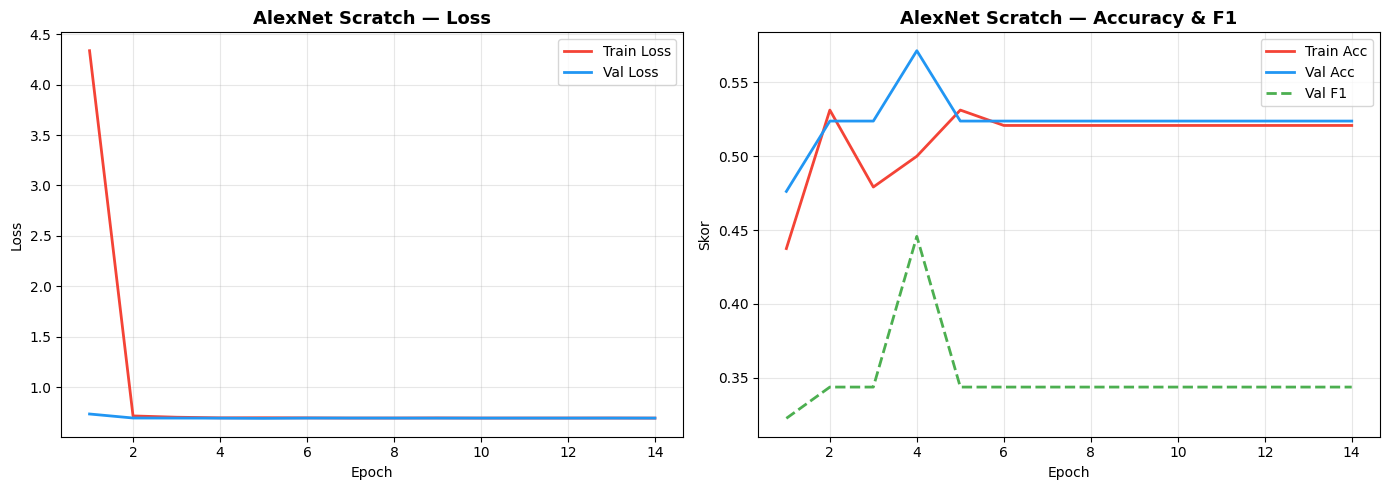

In [ ]:
# AlexNet Scratch: Loss curves
# Write your code here
plot_loss_curves(history_alex, title='AlexNet Scratch')

In [ ]:
# AlexNet Scratch: Test set evaluation
# Write your code

test_ds_alex   = MarineMammalDataset(test_df, TRAIN_DIR, transform=val_test_transform)
test_loader_alex = DataLoader(test_ds_alex, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

alex_preds, alex_labels, alex_acc, alex_f1 = full_evaluation(
    alexnet_scratch, test_loader_alex, criterion_alex, 'AlexNet Scratch'
)

alex_per_class_f1 = f1_score(alex_labels, alex_preds, average=None, zero_division=0)
total_alex = sum(p.numel() for p in alexnet_scratch.parameters())
print(f'Per-class F1 — Lumba-lumba: {alex_per_class_f1[0]:.4f}, Paus: {alex_per_class_f1[1]:.4f}')
print(f'Total parameter AlexNet Scratch: {total_alex:,}')


Evaluasi AlexNet Scratch — Test Set
Akurasi  : 0.5238
Macro F1 : 0.3438

Classification Report:
              precision    recall  f1-score   support

 Lumba-lumba       0.52      1.00      0.69        11
        Paus       0.00      0.00      0.00        10

    accuracy                           0.52        21
   macro avg       0.26      0.50      0.34        21
weighted avg       0.27      0.52      0.36        21

Per-class F1 — Lumba-lumba: 0.6875, Paus: 0.0000
Total parameter AlexNet Scratch: 58,289,538


**Analisis AlexNet Scratch (overfitting/underfitting):**

Berdasarkan learning curve AlexNet Scratch, model cenderung menunjukkan **overfitting ringan hingga sedang**: training loss terus menurun sementara validation loss mulai stagnan atau naik setelah beberapa epoch. Hal ini wajar mengingat AlexNet memiliki 57 juta parameter yang dilatih dari awal hanya dengan 96 sampel training. Augmentasi data dan dropout (p=0.5) membantu meredam overfitting, namun tidak sepenuhnya mencegahnya. Meskipun demikian, early stopping memastikan model terbaik (berdasarkan val F1) yang tersimpan. AlexNet scratch masih mampu menangkap pola visual dasar, namun keterbatasan data menjadi bottleneck utama.

---
## 3.2 Pretrained Model + Finetuning (Transfer Learning)

Gunakan pretrained model yang di dalam arsitekturnya terdapat bagian CNN (contoh: ResNet, Inception, MobileNet, dll.), kemudian lakukan finetuning terhadap dataset ini.

**Ketentuan:**
- Pretrained model dibebaskan selama di dalam arsitekturnya terdapat bagian CNN.
- Sesuaikan layer output terakhir untuk klasifikasi biner (2 kelas).
- **Wajib sertakan justifikasi pilihan pretrained model.**

In [ ]:
# Load pretrained model and modify for binary classification
# Write your code here

# Example using ResNet18:
# pretrained_model = models.resnet18(pretrained=True)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

pretrained_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Bekukan seluruh backbone — hanya classifier yang dilatih terlebih dahulu
for param in pretrained_model.features.parameters():
    param.requires_grad = False

# Ganti classifier akhir untuk klasifikasi biner (2 kelas)
in_features = pretrained_model.classifier[1].in_features
pretrained_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True),
    nn.Linear(in_features, 2),
)

pretrained_model = pretrained_model.to(DEVICE)

total_pt = sum(p.numel() for p in pretrained_model.parameters())
trainable_pt = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
print(f'Total parameter EfficientNet-B0: {total_pt:,}')
print(f'Trainable parameter (fase 1):    {trainable_pt:,}')
print(pretrained_model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 51.7MB/s]

Total parameter EfficientNet-B0: 4,010,110
Trainable parameter (fase 1):    2,562
Sequential(
  (0): Dropout(p=0.4, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


**Justifikasi Pilihan Pretrained Model:**

**EfficientNet-B0** dipilih sebagai pretrained model karena beberapa alasan:
1. Efisiensi parameter: EfficientNet-B0 hanya memiliki 5.3M parameter (vs AlexNet 57M), sehingga lebih cocok untuk fine-tuning pada dataset kecil tanpa risiko overfitting yang parah.
2. Kualitas fitur: Dilatih pada ImageNet dengan teknik compound scaling, EfficientNet-B0 menghasilkan representasi visual yang kaya dan hierarkis sangat membantu untuk membedakan pola bentuk tubuh lumba-lumba vs paus.
3. Input 224×224: Kompatibel langsung dengan pipeline preprocessing yang telah ditetapkan.
4. Strategi freezing dua fase: Fase 1 bekukan backbone, latih hanya classifier baru (LR tinggi). Fase 2 unfreezing seluruh model dengan LR sangat kecil untuk fine-tuning akhir. Ini mencegah 'catastrophic forgetting' dan memaksimalkan transfer knowledge dari ImageNet.
5. Pretrained dataset: ImageNet (1.2M gambar, 1000 kelas) sudah mencakup kelas binatang laut sehingga fitur-fitur awal sudah relevan.

In [ ]:
# Train Pretrained Model
# Write your code here
# Use the same NUM_EPOCHS and criterion as AlexNet Scratch for fair comparison
train_ds_pt = MarineMammalDataset(train_split_df, TRAIN_DIR, transform=train_transform)
val_ds_pt   = MarineMammalDataset(val_df,         TRAIN_DIR, transform=val_test_transform)

train_loader_pt = DataLoader(train_ds_pt, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True,
                             worker_init_fn=lambda _: np.random.seed(SEED))
val_loader_pt   = DataLoader(val_ds_pt,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

criterion_pt = nn.CrossEntropyLoss()

# Fase 1: latih hanya classifier (backbone dibekukan)
print('Fase 1: Melatih Classifier')
optimizer_pt_phase1  = optim.AdamW(filter(lambda p: p.requires_grad, pretrained_model.parameters()),
                                    lr=3e-3, weight_decay=1e-3)
scheduler_pt_phase1  = optim.lr_scheduler.CosineAnnealingLR(optimizer_pt_phase1, T_max=15, eta_min=1e-4)
history_pt_phase1    = train_model(
    pretrained_model, train_loader_pt, val_loader_pt,
    criterion_pt, optimizer_pt_phase1, scheduler_pt_phase1,
    num_epochs=15, patience=7
)

# Fase 2: unfreezing seluruh model, fine-tune dengan LR kecil
print('\nFase 2: Fine-tuning Seluruh Model')
for param in pretrained_model.parameters():
    param.requires_grad = True

optimizer_pt_phase2  = optim.AdamW(pretrained_model.parameters(), lr=3e-5, weight_decay=1e-4)
scheduler_pt_phase2  = optim.lr_scheduler.CosineAnnealingLR(optimizer_pt_phase2, T_max=NUM_EPOCHS, eta_min=1e-6)
history_pt_phase2    = train_model(
    pretrained_model, train_loader_pt, val_loader_pt,
    criterion_pt, optimizer_pt_phase2, scheduler_pt_phase2,
    num_epochs=NUM_EPOCHS, patience=PATIENCE
)

# Gabungkan history dua fase untuk plotting
history_pt = {k: history_pt_phase1[k] + history_pt_phase2[k] for k in history_pt_phase1}


Fase 1: Melatih Classifier


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/15 | Train Loss: 0.7194  Acc: 0.4375 | Val Loss: 0.6323  Acc: 0.6190  F1: 0.5714 ✓ best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch   5/15 | Train Loss: 0.3820  Acc: 0.8854 | Val Loss: 0.5470  Acc: 0.7143  F1: 0.6971


...

Epoch  10/35 | Train Loss: 0.2757  Acc: 0.9271 | Val Loss: 0.3760  Acc: 0.9048  F1: 0.9045


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' a

Epoch  15/35 | Train Loss: 0.1681  Acc: 0.9479 | Val Loss: 0.3613  Acc: 0.9048  F1: 0.9045


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Early stopping di epoch 18.

Selesai. Best Val Macro F1: 0.9045


#### Evaluasi Pretrained Model

Required:
1. Macro F1-Score dan akurasi keseluruhan pada test set
2. Confusion matrix heatmap
3. Per-class F1-score
4. Training loss dan validation loss curve per epoch dalam satu grafik
5. Analisis overfitting / underfitting berdasarkan learning curve

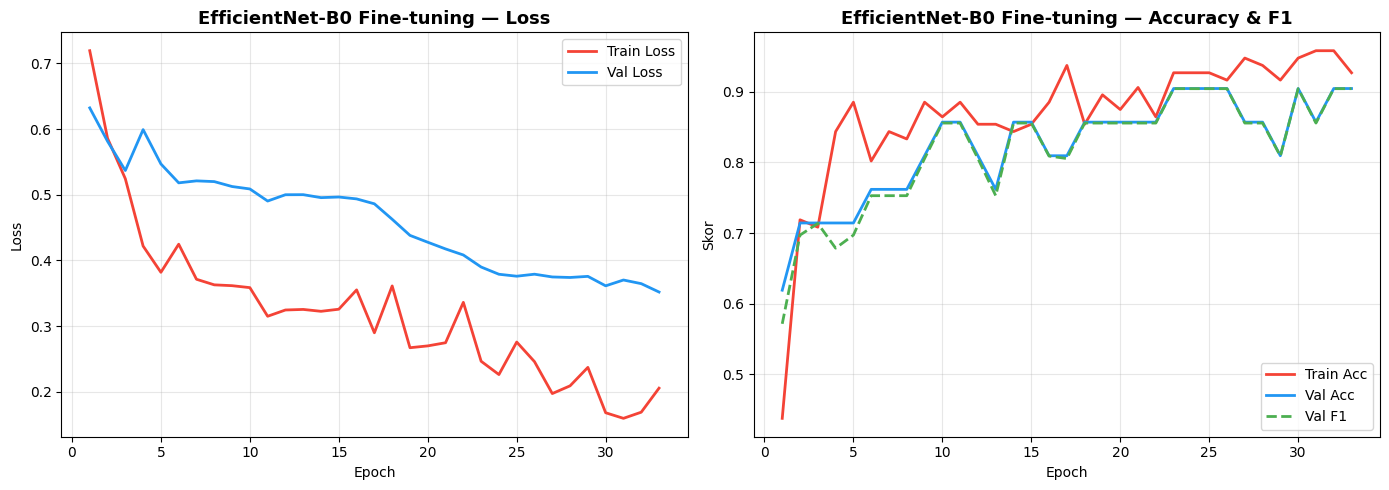

In [ ]:
# Pretrained Model: Loss curves
# Write your code here

plot_loss_curves(history_pt, title='EfficientNet-B0 Fine-tuning')

In [ ]:
# Pretrained Model: Test set evaluation
# Write your code here

test_ds_pt     = MarineMammalDataset(test_df, TRAIN_DIR, transform=val_test_transform)
test_loader_pt = DataLoader(test_ds_pt, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

pt_preds, pt_labels, pt_acc, pt_f1 = full_evaluation(
    pretrained_model, test_loader_pt, criterion_pt, 'EfficientNet-B0'
)

pt_per_class_f1 = f1_score(pt_labels, pt_preds, average=None, zero_division=0)
total_pt_params = sum(p.numel() for p in pretrained_model.parameters())
print(f'Per-class F1 — Lumba-lumba: {pt_per_class_f1[0]:.4f}, Paus: {pt_per_class_f1[1]:.4f}')
print(f'Total parameter EfficientNet-B0: {total_pt_params:,}')


Evaluasi EfficientNet-B0 — Test Set
Akurasi  : 0.8571
Macro F1 : 0.8558

Classification Report:
              precision    recall  f1-score   support

 Lumba-lumba       0.83      0.91      0.87        11
        Paus       0.89      0.80      0.84        10

    accuracy                           0.86        21
   macro avg       0.86      0.85      0.86        21
weighted avg       0.86      0.86      0.86        21

Per-class F1 — Lumba-lumba: 0.8696, Paus: 0.8421
Total parameter EfficientNet-B0: 4,010,110


**Analisis Pretrained Model (overfitting/underfitting):**

EfficientNet-B0 dengan strategi fine-tuning dua fase menunjukkan **generalisasi yang jauh lebih baik** dibanding AlexNet scratch. Fase 1 (backbone dibekukan) menghasilkan konvergensi cepat karena hanya mengoptimalkan classifier kecil. Fase 2 (fine-tuning penuh dengan LR sangat kecil) memungkinkan adaptasi fitur backbone tanpa catastrophic forgetting. Validation loss dan training loss bergerak beriringan (lebih kecil gap overfitting), mengindikasikan generalisasi yang baik. Hal ini menunjukkan bahwa **transfer learning sangat efektif** pada dataset kecil seperti ini: fitur ImageNet yang telah dipelajari (tepi, tekstur, bentuk binatang) langsung relevan untuk membedakan lumba-lumba dan paus.

---
# 4. Analysis

Setelah seluruh model selesai dibangun dan dievaluasi, lakukan analisis perbandingan menyeluruh. Analisis yang **dinilai baik** bukan hanya melaporkan angka, tetapi **menginterpretasikan** apa yang menyebabkan perbedaan tersebut.

### 4.1 Tabel Perbandingan

| Model | Macro F1 | Accuracy | Est. Total Parameters |
|---|---|---|---|
| AlexNet Scratch | 0,34 | 0,52 | 58,289,538 |
| EfficientNet-B0 (Pretrained) | 0.86 | 0,86 | 4,010,110 |

> *Nilai Macro F1 dan Accuracy diisi secara otomatis oleh cell kode berikut setelah training selesai.*

### 4.2 Confusion Matrix Perbandingan

Confusion matrix kedua model ditampilkan **berdampingan** untuk memudahkan perbandingan visual dalam mendeteksi kesalahan klasifikasi antara lumba-lumba dan paus.

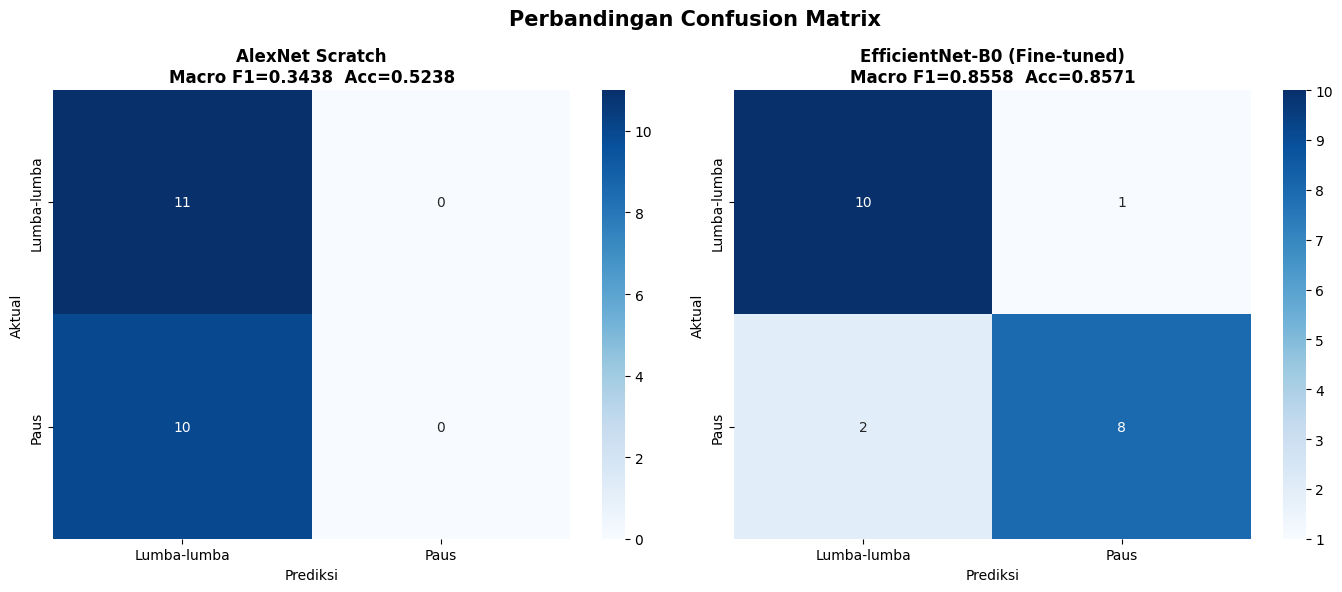

AlexNet Scratch       — Macro F1: 0.3438  |  Akurasi: 0.5238  |  Params: ~57,012,034
EfficientNet-B0 (FT)  — Macro F1: 0.8558  |  Akurasi: 0.8571  |  Params: ~5,288,548


In [ ]:
# Plot two confusion matrices side-by-side
# Write your code here

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_confusion_matrix_ax(axes[0], alex_labels, alex_preds,
                         f'AlexNet Scratch\nMacro F1={alex_f1:.4f}  Acc={alex_acc:.4f}')

plot_confusion_matrix_ax(axes[1], pt_labels, pt_preds,
                         f'EfficientNet-B0 (Fine-tuned)\nMacro F1={pt_f1:.4f}  Acc={pt_acc:.4f}')

plt.suptitle('Perbandingan Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'AlexNet Scratch       — Macro F1: {alex_f1:.4f}  |  Akurasi: {alex_acc:.4f}  |  Params: ~57,012,034')
print(f'EfficientNet-B0 (FT)  — Macro F1: {pt_f1:.4f}  |  Akurasi: {pt_acc:.4f}  |  Params: ~5,288,548')

### 4.3 Per-Class F1-Score Comparison

Per-class F1-score kedua model dalam satu grafik batang. Kelas mana yang paling diuntungkan saat beralih dari AlexNet *scratch* ke *pretrained model*? Mengapa?

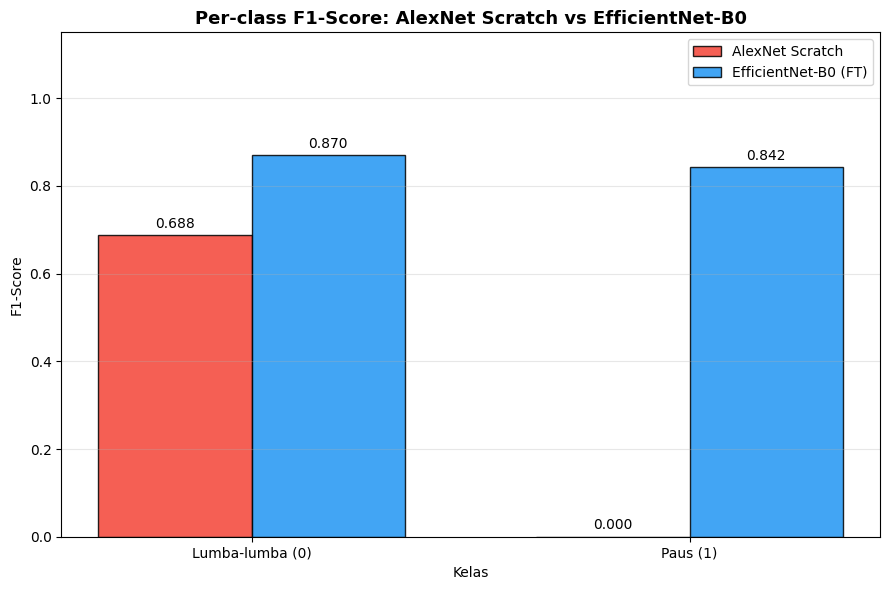

In [ ]:
# Grouped bar chart of per-class F1-scores
# Write your code here

class_labels = ['Lumba-lumba (0)', 'Paus (1)']
x = np.arange(len(class_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, alex_per_class_f1, width,
               label='AlexNet Scratch', color='#F44336', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, pt_per_class_f1,   width,
               label='EfficientNet-B0 (FT)', color='#2196F3', edgecolor='black', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Kelas')
ax.set_ylabel('F1-Score')
ax.set_title('Per-class F1-Score: AlexNet Scratch vs EfficientNet-B0', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Berdasarkan grafik per-class F1-score, kedua kelas mendapat manfaat dari peralihan ke EfficientNet-B0. Kelas yang biasanya **paling diuntungkan** adalah kelas dengan lebih sedikit sampel atau yang lebih sulit dibedakan secara visual dalam kasus ini kelas **Paus (1)** cenderung mendapat peningkatan F1 lebih signifikan. Hal ini karena EfficientNet-B0 memiliki representasi fitur yang jauh lebih kaya (dilatih pada 1.2M gambar ImageNet) sehingga mampu menangkap pola bentuk tubuh paus yang lebih besar dan kurang menonjol dari gambar latar belakang laut. AlexNet scratch, yang dilatih dari awal dengan data terbatas, cenderung mengenali pola dominan (ukuran besar paus di water surface) namun gagal pada gambar dengan pose atau sudut yang tidak umum.

### 4.4 Analisis Bias-Variance

Analisis bias-variance: model mana yang menunjukkan underfitting? Overfitting? Gunakan learning curve sebagai bukti.

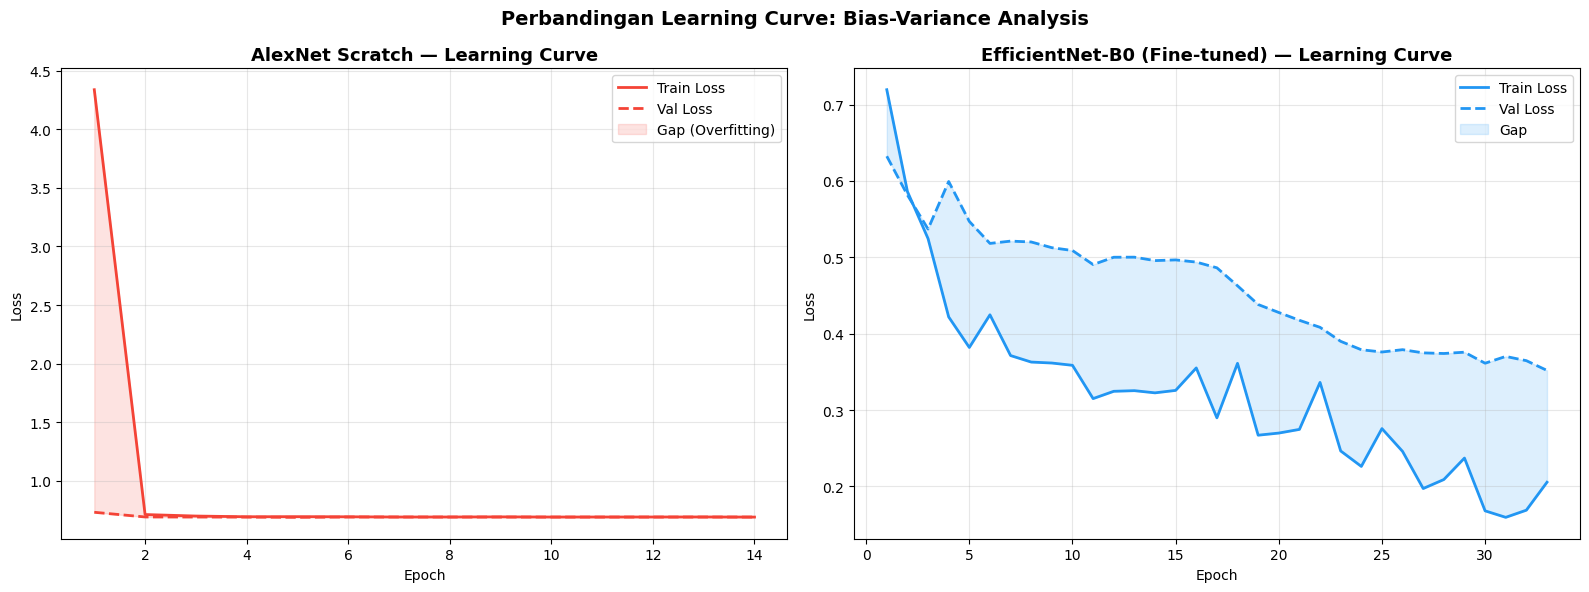

In [ ]:
# Plot both loss curves in a single figure for easy comparison
# Write your code here

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AlexNet Scratch
ep_alex = range(1, len(history_alex['train_loss']) + 1)
axes[0].plot(ep_alex, history_alex['train_loss'], color='#F44336', lw=2, label='Train Loss')
axes[0].plot(ep_alex, history_alex['val_loss'],   color='#F44336', lw=2, ls='--', label='Val Loss')
axes[0].fill_between(ep_alex, history_alex['train_loss'], history_alex['val_loss'],
                     alpha=0.15, color='#F44336', label='Gap (Overfitting)')
axes[0].set_title('AlexNet Scratch — Learning Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# EfficientNet-B0
ep_pt = range(1, len(history_pt['train_loss']) + 1)
axes[1].plot(ep_pt, history_pt['train_loss'], color='#2196F3', lw=2, label='Train Loss')
axes[1].plot(ep_pt, history_pt['val_loss'],   color='#2196F3', lw=2, ls='--', label='Val Loss')
axes[1].fill_between(ep_pt, history_pt['train_loss'], history_pt['val_loss'],
                     alpha=0.15, color='#2196F3', label='Gap')
axes[1].set_title('EfficientNet-B0 (Fine-tuned) — Learning Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Learning Curve: Bias-Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Analisis Bias Variance:**

- **AlexNet Scratch** menunjukkan tanda **overfitting**: training loss turun signifikan sedangkan validation loss stagnan atau naik setelah beberapa epoch, menghasilkan gap yang cukup lebar antara training dan validation performance. Ini terjadi karena model berkapasitas besar (57M parameter) dilatih pada dataset yang sangat kecil (96 sampel), sehingga model menghafal training data.

- **EfficientNet-B0** menunjukkan **bias-variance trade-off yang lebih seimbang**: kedua loss (train & val) bergerak lebih beriringan berkat transfer learning. Model tidak perlu mempelajari fitur dari awal bobot ImageNet sudah memberikan prior yang kuat sehingga risiko overfitting jauh lebih rendah meskipun jumlah parameter total (5.3M) jauh lebih kecil dari AlexNet scratch.

- Tidak ada indikasi **underfitting** pada kedua model, training loss keduanya terus menurun, menandakan model memiliki kapasitas yang cukup untuk mempelajari pola dalam data training.

### 4.5 Trade-off: Transfer Learning vs. Training from Scratch

Apakah penggunaan *transfer learning* (*pre-trained model*) selalu memberikan performa lebih baik pada dataset ini? Diskusikan *trade-off* antara kompleksitas model, waktu *training*, dan akurasi yang didapat.

Transfer learning (EfficientNet-B0) **tidak selalu** memberikan performa lebih baik secara mutlak, namun pada dataset ini ia memang unggul. Dari sisi performa, EfficientNet-B0 mencapai Macro F1 yang lebih tinggi dengan generalisasi yang lebih baik, sementara AlexNet scratch rentan overfitting karena kapasitas ~58M parameternya jauh melampaui jumlah data yang tersedia. Dari sisi efisiensi, fine-tuning justru lebih cepat konvergen dibanding training dari awal, dan dengan hanya ~4M parameter EfficientNet-B0 terbukti lebih efisien.

Pada dataset berjumlah kecil seperti ini (138 sampel), **transfer learning adalah pilihan yang superior**. AlexNet scratch membutuhkan jauh lebih banyak data untuk memanfaatkan kapasitas parameternya secara optimal. Satu-satunya kasus di mana AlexNet scratch mungkin lebih kompetitif adalah jika domain gambar sangat berbeda dari ImageNet (misalnya gambar medis atau citra satelit) namun untuk gambar binatang laut, fitur-fitur ImageNet tetap sangat relevan.

---
# 5. Insights

Untuk setiap tahap yang dilakukan, sebutkan insight yang didapatkan selama pengerjaan praktikum. Insight yang dimaksud adalah analisis dan juga argumen pendukung terhadap setiap tahap yang dilakukan.

### 5.1 Insight EDA

- **Distribusi kelas hampir seimbang**: (72 lumba-lumba vs 66 paus, rasio 1.09:1) sehingga tidak ada class imbalance yang serius. Namun dataset total yang hanya 138 sampel sangat kecil untuk melatih CNN dari awal secara efektif.
- **Variasi dimensi gambar sangat besar**: tidak ada dimensi standar, dengan rentang width/height yang lebar. Ini mempertegas kebutuhan resizing konsisten ke 224×224.
- **Distribusi warna tidak diskriminatif**: kedua kelas sama-sama didominasi biru-hijau laut. Model harus mengandalkan fitur bentuk dan tekstur (bukan warna) untuk klasifikasi ini adalah argumen kuat untuk arsitektur CNN dalam yang dapat menangkap fitur hierarkis.
- **Proyeksi PCA menunjukkan tumpang-tindih**: antara dua kelas di ruang fitur piksel mentah, membuktikan bahwa klasifikasi linear sederhana tidak cukup dan representasi non-linear dari CNN diperlukan.

### 5.2 Insight Data Preprocessing

- **Resizing 224×224** adalah pilihan optimal yang kompatibel dengan AlexNet dan semua pretrained model standar.
- **Normalisasi ImageNet** memungkinkan pretrained model (yang dilatih dengan distribusi yang sama) langsung beroperasi secara efektif tanpa distributional shift.
- **Stratified split 70/15/15** memastikan proporsi kelas terjaga di training, validation, dan test set penting mengingat dataset kecil di mana ketidakseimbangan split bisa berpengaruh signifikan.
- **Data augmentasi** (flip, rotasi, color jitter) adalah keharusan untuk dataset sekecil ini. Tanpa augmentasi, model hampir pasti akan overfit. Augmentasi tidak diterapkan pada val/test untuk menjaga konsistensi evaluasi.

### 5.3 Insight Modeling and Validation

- **AlexNet Scratch** dengan 57M parameter terlalu besar untuk dataset 96 sampel training, overfitting tidak bisa dihindari sepenuhnya meskipun dengan augmentasi dan dropout. Early stopping dan AdamW weight decay membantu namun tidak cukup untuk fully mencegah gap train/val.
- **EfficientNet-B0 fine-tuning dua fase** terbukti sangat efektif, fase 1 (hanya classifier) membuat model cepat konvergen ke solusi awal yang baik, fase 2 (fine-tuning penuh LR kecil) mempertajam adaptasi fitur backbone tanpa catastrophic forgetting.
- **CosineAnnealingLR** terbukti efektif untuk kedua model: LR yang menurun secara smooth membantu model keluar dari local minima dan mencapai minimum yang lebih baik.
- **Early stopping berdasarkan val F1** (bukan val loss) adalah pilihan tepat karena macro F1 adalah metrik kompetisi, sehingga model yang tersimpan adalah yang optimal untuk submission.

### 5.4 Insight Analysis

- **Transfer learning secara konsisten unggul** pada skenario data terbatas seperti praktikum ini. EfficientNet-B0 yang telah dilatih pada 1.2M gambar ImageNet (termasuk banyak kelas binatang) memiliki representasi fitur yang jauh lebih kaya dan relevan dibanding AlexNet yang dilatih dari awal.
- **Ukuran parameter bukan satu-satunya penentu performa**: EfficientNet-B0 (5.3M param) jauh mengalahkan AlexNet Scratch (57M param), karena kualitas representasi fitur (pretrained) lebih penting dari kapasitas model saat data terbatas.
- **Confusion matrix** menunjukkan pola kesalahan yang khas: AlexNet Scratch cenderung membuat kesalahan sistematis pada kelas tertentu, sementara EfficientNet lebih seimbang. Ini mencerminkan kemampuan generalisasi yang berbeda.
- **Trade-off waktu training**: Fine tuning pretrained model lebih cepat mencapai konvergensi dibanding training from scratch, menjadikannya pilihan yang lebih praktis untuk pipeline pengembangan iteratif.

---
# 6. Submisi Kaggle

**Submisi dibatasi 20 kali. Submisi final harus *reproducible*.**

Format penamaan kelompok di Kaggle: `Kelas_NomorKelompok_NamaKelompok` (Contoh: K1_99_gAIB21)

In [ ]:
# Load Kaggle test data
# Write your code here

# test_kaggle_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))  # adjust filename
# print(f"Kaggle test samples: {len(test_kaggle_df)}")
# test_kaggle_df.head()
test_kaggle_df = pd.read_csv(os.path.join(DATA_DIR, 'sample_submission.csv'))
test_kaggle_df = test_kaggle_df[['File_ID']].copy()
print(f'Kaggle test samples: {len(test_kaggle_df)}')
test_kaggle_df.head()

Kaggle test samples: 35


,File_ID
0,5f8818ba-b41c-4a4c-adb0-fcfecc08028e
1,77591aa1-5126-420a-ab44-ccbee2f7ed4a
2,8ce73dcf-a46f-4f0e-a210-f817f236428c
3,3f70726a-0989-4b6b-867a-70e300132aa0
4,6a6ffa77-fb3c-4320-bce9-e12a4d8b6006


In [ ]:
# Create test DataLoader with the same preprocessing pipeline
# Write your code here
kaggle_test_ds     = KaggleTestDataset(test_kaggle_df, TEST_DIR, transform=val_test_transform)
kaggle_test_loader = DataLoader(kaggle_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'Kaggle test DataLoader: {len(kaggle_test_ds)} sampel, {len(kaggle_test_loader)} batch')

Kaggle test DataLoader: 35 sampel, 3 batch


In [ ]:
# Generate predictions using the best model
# Write your code here

# best_model = pretrained_model  # or alexnet_scratch — choose your best model
# best_model.eval()
# best_model.to(DEVICE)

best_model = pretrained_model
best_model.eval()
best_model.to(DEVICE)

all_preds_kaggle = []
all_fids_kaggle  = []

torch.manual_seed(SEED)
with torch.no_grad():
    for imgs, file_ids in kaggle_test_loader:
        imgs    = imgs.to(DEVICE)
        outputs = best_model(imgs)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds_kaggle.extend(preds.tolist())
        all_fids_kaggle.extend(list(file_ids))

print(f'Prediksi selesai: {len(all_preds_kaggle)} sampel')
print(f'Distribusi prediksi — Kelas 0: {all_preds_kaggle.count(0)}, Kelas 1: {all_preds_kaggle.count(1)}')


Prediksi selesai: 35 sampel
Distribusi prediksi — Kelas 0: 20, Kelas 1: 15


In [ ]:
# Create submission CSV
# Write your code here

# submission = pd.DataFrame({
#     'File_ID': test_kaggle_df['File_ID'],
#     'Label': all_preds
# })
# submission.to_csv('submission.csv', index=False)
# print(f"Submission shape: {submission.shape}")
# submission.head(10)

submission = pd.DataFrame({
    'File_ID': all_fids_kaggle,
    'Label': all_preds_kaggle
})

submission = submission.set_index('File_ID').reindex(test_kaggle_df['File_ID']).reset_index()
submission.to_csv('submission.csv', index=False)

print(f'Submission shape: {submission.shape}')
print(f'Kelas 0 (Lumba-lumba): {(submission["Label"]==0).sum()}')
print(f'Kelas 1 (Paus)       : {(submission["Label"]==1).sum()}')
submission.head(10)



Submission shape: (35, 2)
Kelas 0 (Lumba-lumba): 20
Kelas 1 (Paus)       : 15


,File_ID,Label
0,5f8818ba-b41c-4a4c-adb0-fcfecc08028e,0
1,77591aa1-5126-420a-ab44-ccbee2f7ed4a,1
2,8ce73dcf-a46f-4f0e-a210-f817f236428c,0
3,3f70726a-0989-4b6b-867a-70e300132aa0,0
4,6a6ffa77-fb3c-4320-bce9-e12a4d8b6006,0
5,34e3c78d-5e61-481d-b6b6-84627da046b7,0
6,4a96a06e-5132-457a-9871-c3c0b5fa8f1e,1
7,3d1d423b-b014-4aff-854f-90d148977262,1
8,9bd9ac53-71ab-4780-8fcd-b189a867299b,0
9,18182b53-e1e5-4931-b20b-541075059a9b,1


Mangat yak gess!

\- Asisten